# Volatility Modeling: GARCH vs. Market-Implied Volatility
### A Black-Scholes Options Pricing Analysis Across Three Decades

**Author:** Nathan Fleck
**Date:** April 2026
**Data Sources:** Yahoo Finance (SPY, QQQ, GLD), FRED (VIX, VIX3M, 3-Month T-Bill Rate)

---

## Overview

Black-Scholes is the dominant framework for options pricing, but it has a flaw, it's built on the assumption that volatility is constant over time. This assumption is empirically false; annualized realized volatility on SPY has ranged from under 8% in the calmest years to over 60% during the 2008 financial crisis, nearly a 9× difference across the same underlying asset.

This project quantifies that gap across 30+ years of data. We fit GARCH related volatility models to SPY returns, benchmark them against market-implied volatility (VIX), and measure how much Black-Scholes misprices options when the constant-vol assumption breaks down across different market regimes. The analysis extends to three asset classes and introduces the Heston (1993) stochastic volatility model as a theoretically complete alternative.

## Project Structure
1. Setup & Imports
2. Data Collection
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis
5. GARCH & GJR-GARCH Volatility Modeling
6. Multi-Asset Volatility Analysis (SPY, QQQ, GLD)
7. Volatility Regime Classification
8. Black-Scholes Pricing Across Regimes
9. Insights & Conclusions

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from fredapi import Fred
from scipy import stats
from scipy.stats import norm
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# ── Configuration ─────────────────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()
FRED_API_KEY = os.getenv('FRED_API_KEY')  # only needed if fred_data.csv is missing
START_DATE   = '1993-01-01'   # SPY inception; QQQ starts 1999, GLD starts 2004
END_DATE     = '2024-12-31'
TICKERS      = ['SPY', 'QQQ', 'GLD']
# ──────────────────────────────────────────────────────────────────────────────

print('All imports successful.')

All imports successful.


## 2. Data Collection

We collect six data series spanning 1993–2024:
- **SPY** — S&P 500 ETF, daily OHLCV (30+ years, 7,838 trading days)
- **QQQ** — Nasdaq-100 ETF (technology-heavy), from 1999
- **GLD** — Gold ETF, from 2004
- **VIX** — CBOE 30-day implied volatility index, from FRED
- **VIX3M** — CBOE 93-day implied volatility index, from FRED
- **3-Month T-Bill Rate** — Dynamic risk-free rate used in Black-Scholes pricing, from FRED

All series are saved to CSV on the first run; subsequent runs load from disk.

In [2]:
def download_equities(tickers, start, end, save_path):
    print(f'Downloading {tickers} from Yahoo Finance...')
    raw   = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    close = raw['Close'].copy()
    close.index = pd.to_datetime(close.index)
    close.to_csv(save_path)
    print(f'Saved to {save_path} ({len(close)} rows)')
    return close

def download_fred_series(api_key, series_dict, start, end, save_path):
    fred   = Fred(api_key=api_key)
    frames = {}
    for name, sid in series_dict.items():
        print(f'  Downloading {name} ({sid})...')
        s = fred.get_series(sid, observation_start=start, observation_end=end).dropna()
        frames[name] = s
    df = pd.DataFrame(frames)
    df.index = pd.to_datetime(df.index)
    df.to_csv(save_path)
    print(f'Saved to {save_path}')
    return df

EQUITY_CSV = 'equity_close.csv'
FRED_CSV   = 'fred_data.csv'
FRED_SERIES = {
    'VIX'   : 'VIXCLS',   # 30-day implied vol (1990-present)
    'VIX3M' : 'VXVCLS',   # 93-day implied vol (2007-present)
    'TBILL' : 'DTB3'       # 3-month T-bill daily rate (1954-present)
}

if os.path.exists(EQUITY_CSV):
    close_prices = pd.read_csv(EQUITY_CSV, index_col=0, parse_dates=True)
    print(f'Loaded equities from {EQUITY_CSV} ({len(close_prices)} rows)')
else:
    close_prices = download_equities(TICKERS, START_DATE, END_DATE, EQUITY_CSV)

if os.path.exists(FRED_CSV):
    fred_data = pd.read_csv(FRED_CSV, index_col=0, parse_dates=True)
    print(f'Loaded FRED data from {FRED_CSV} ({len(fred_data)} rows)')
else:
    print('Downloading FRED data...')
    fred_data = download_fred_series(FRED_API_KEY, FRED_SERIES, START_DATE, END_DATE, FRED_CSV)

print(f'\nEquity data: {close_prices.index[0].date()} to {close_prices.index[-1].date()}')
print(f'FRED data:   {fred_data.index[0].date()} to {fred_data.index[-1].date()}')
print(f'\nFirst date each asset has data:')
print(close_prices.apply(lambda c: c.dropna().index[0].date()))

Loaded equities from equity_close.csv (8037 rows)
Loaded FRED data from fred_data.csv (8089 rows)

Equity data: 1993-01-29 to 2024-12-30
FRED data:   1993-01-04 to 2024-12-31

First date each asset has data:
GLD    2004-11-18
QQQ    1999-03-10
SPY    1993-01-29
dtype: object


## 3. Data Cleaning & Preprocessing

In [3]:
def clean_prices(df):
    """Sort by date, forward-fill gaps up to 3 days (handles holidays and early closes)."""
    return df.sort_index().ffill(limit=3)

def clean_fred(df):
    """Forward-fill FRED data (weekends/holidays) and convert units."""
    df = df.sort_index().ffill(limit=5)
    for col in ['VIX', 'VIX3M']:
        if col in df.columns:
            df[col] = df[col] / 100        # percentage → decimal
    if 'TBILL' in df.columns:
        df['TBILL'] = df['TBILL'] / 100    # annual % → decimal
    return df

close_prices = clean_prices(close_prices)
fred_data    = clean_fred(fred_data)

# ── SPY full history (1993–2024) for the main single-asset analysis ───────────
spy = pd.DataFrame({'Close': close_prices['SPY'].dropna()})
spy['Log_Return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy['Pct_Return'] = spy['Close'].pct_change()
spy['MA_50']      = spy['Close'].rolling(50).mean()
spy['MA_200']     = spy['Close'].rolling(200).mean()
spy['RV_21']      = spy['Log_Return'].rolling(21).std()  * np.sqrt(252)
spy['RV_63']      = spy['Log_Return'].rolling(63).std()  * np.sqrt(252)
spy = spy.dropna()

# Align SPY with FRED on common trading days
common_spy   = spy.index.intersection(fred_data.index)
spy_aligned  = spy.loc[common_spy]
fred_aligned = fred_data.loc[common_spy]

# ── Multi-asset: only rows where SPY, QQQ, AND GLD all have data (2004+) ─────
multi_close   = close_prices.dropna()
multi_returns = np.log(multi_close / multi_close.shift(1)).dropna()

print(f'SPY full history:     {spy.index[0].date()} → {spy.index[-1].date()}  ({len(spy):,} days)')
print(f'SPY + FRED aligned:   {spy_aligned.index[0].date()} → {spy_aligned.index[-1].date()}  ({len(spy_aligned):,} days)')
print(f'Multi-asset (all 3):  {multi_close.index[0].date()} → {multi_close.index[-1].date()}  ({len(multi_close):,} days)')

SPY full history:     1993-11-11 → 2024-12-30  (7,838 days)
SPY + FRED aligned:   1993-11-11 → 2024-12-30  (7,838 days)
Multi-asset (all 3):  2004-11-18 → 2024-12-30  (5,062 days)


## 4. Exploratory Data Analysis

### 4.1 Thirty Years of SPY — Price History & Bear Market Regimes

A **bear market regime** is defined here as any period where SPY trades below its 200-day moving average — a widely-used threshold that cleanly identifies all major drawdowns. Over the full sample, SPY spent **23.2% of all trading days** in a bear regime, with a maximum drawdown of **−55.2%** during the 2008 financial crisis.

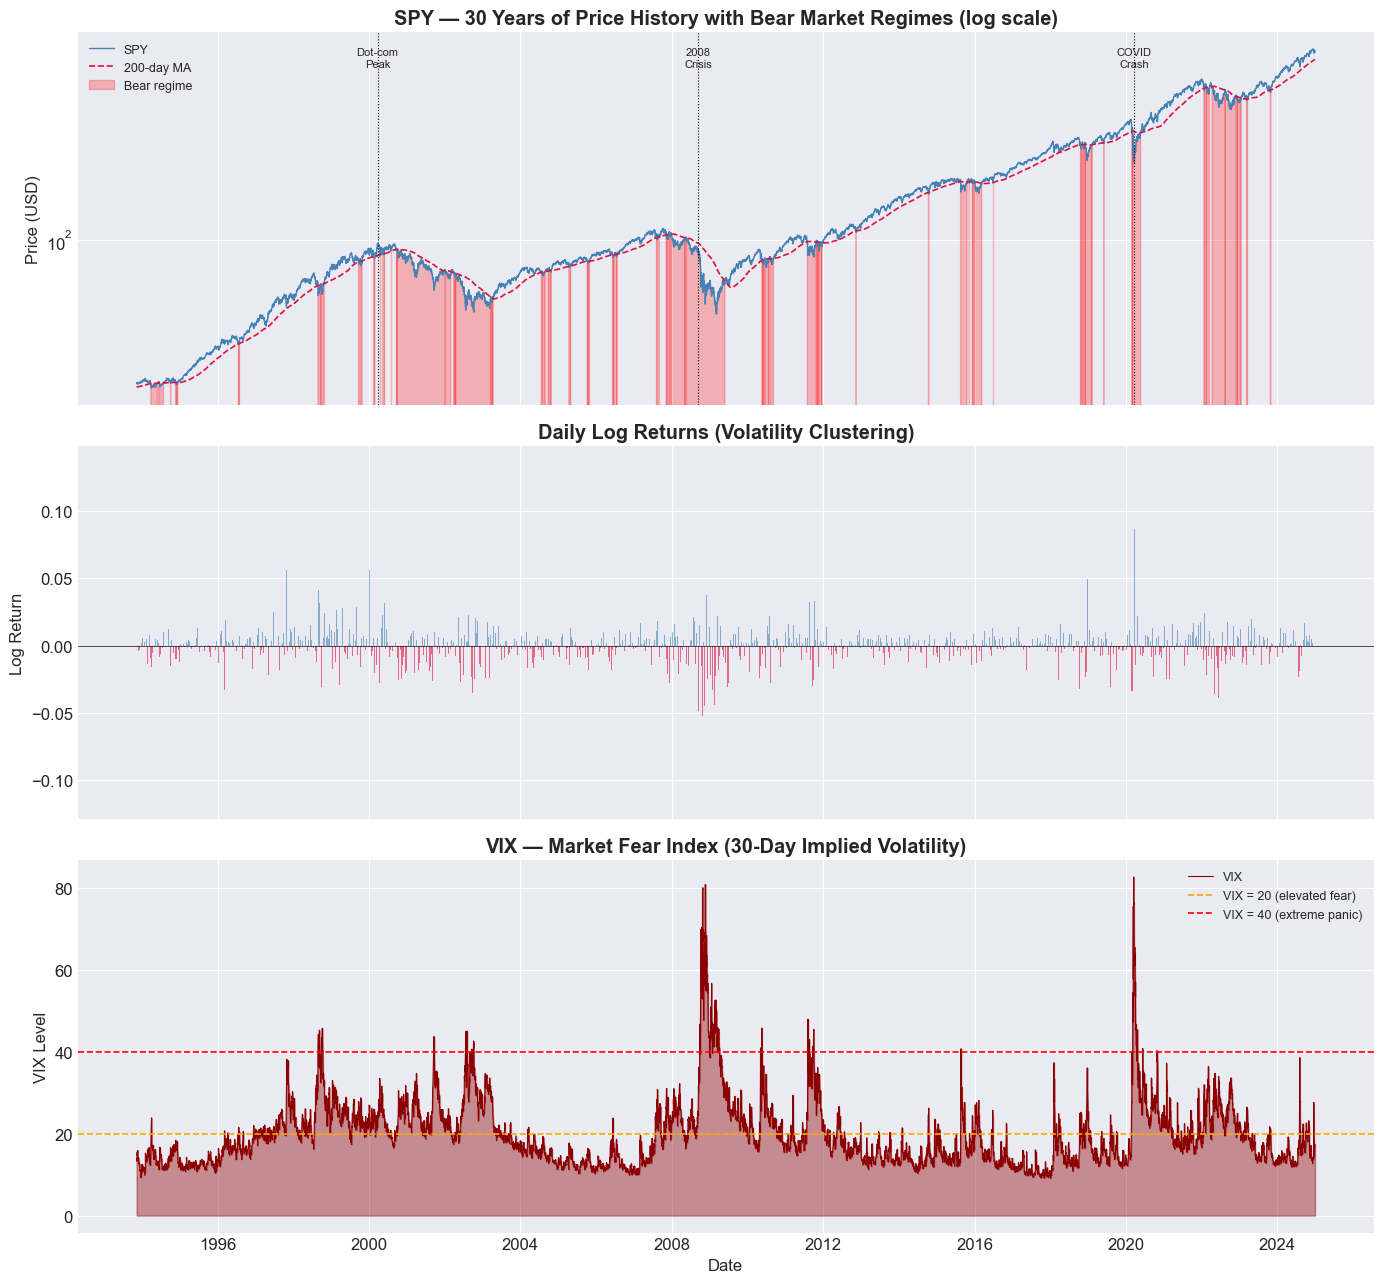

SPY spent 23.2% of all trading days in a bear regime (below MA-200)


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# — Price + bear/bull regime shading
ax = axes[0]
ax.plot(spy.index, spy['Close'],  linewidth=1,   color='steelblue', label='SPY')
ax.plot(spy.index, spy['MA_200'], linewidth=1.2, color='crimson',   linestyle='--', label='200-day MA')
ax.fill_between(spy.index, 0, spy['Close'],
                where=(spy['Close'] < spy['MA_200']),
                alpha=0.25, color='red', label='Bear regime')
for date_str, label in {'2000-03-24': 'Dot-com\nPeak',
                         '2008-09-15': '2008\nCrisis',
                         '2020-03-23': 'COVID\nCrash'}.items():
    d = pd.Timestamp(date_str)
    if d in spy.index:
        ax.axvline(d, color='black', linewidth=0.8, linestyle=':')
        ax.text(d, spy['Close'].max() * 0.85, label, fontsize=8, ha='center')
ax.set_title('SPY — 30 Years of Price History with Bear Market Regimes (log scale)', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=9)

# — Daily log returns (volatility clustering is visible)
ax = axes[1]
colors = np.where(spy['Log_Return'] >= 0, 'steelblue', 'crimson')
ax.bar(spy.index, spy['Log_Return'], width=1, color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Daily Log Returns (Volatility Clustering)', fontweight='bold')
ax.set_ylabel('Log Return')

# — VIX over time
ax = axes[2]
ax.fill_between(fred_aligned.index, fred_aligned['VIX'] * 100, alpha=0.4, color='darkred')
ax.plot(fred_aligned.index, fred_aligned['VIX'] * 100, linewidth=0.8, color='darkred', label='VIX')
ax.axhline(20, color='orange', linewidth=1.2, linestyle='--', label='VIX = 20 (elevated fear)')
ax.axhline(40, color='red',    linewidth=1.2, linestyle='--', label='VIX = 40 (extreme panic)')
ax.set_title('VIX — Market Fear Index (30-Day Implied Volatility)', fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_spy_history.png', dpi=150, bbox_inches='tight')
plt.show()

bear_pct = (spy['Close'] < spy['MA_200']).mean()
print(f'SPY spent {bear_pct:.1%} of all trading days in a bear regime (below MA-200)')

### 4.2 Return Distribution — Fat Tails and the Failure of Normality

Black-Scholes assumes log-returns follow a normal distribution. SPY's empirical distribution rejects this: excess kurtosis of **10.89** (vs. 0 for a normal distribution) confirms that extreme moves occur far more frequently than the model predicts. Skewness of **−0.294** reflects an asymmetric distribution, large down days are more common than equivalently-sized up days. The Jarque-Bera test rejects normality at every conventional significance level (p ≈ 0 across 7,838 observations).

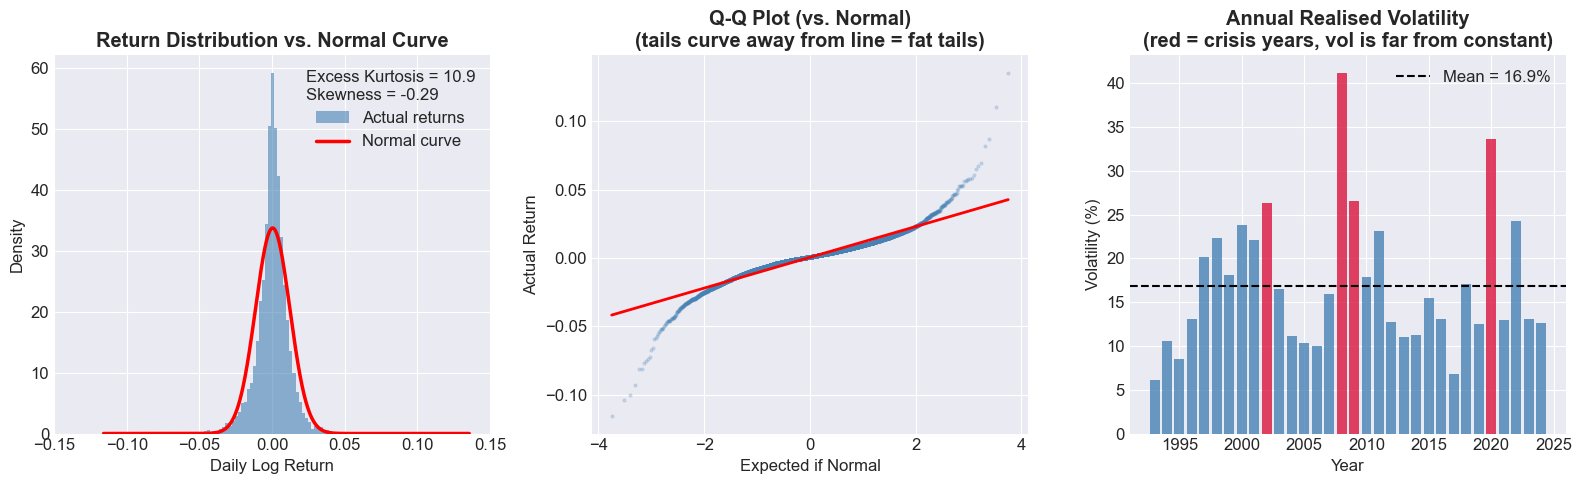

Excess kurtosis: 10.89  (a normal distribution = 0; higher = fatter tails)
Skewness:        -0.294  (negative = more big down days than up days)
Jarque-Bera p:   0.00e+00  (p < 0.05 → reject normality)
Conclusion: SPY returns are definitively NOT normally distributed over 7,838 days.


In [5]:
returns   = spy['Log_Return'].dropna()
mu, sigma = returns.mean(), returns.std()
kurtosis  = stats.kurtosis(returns)
skewness  = stats.skew(returns)
jb_stat, jb_p = stats.jarque_bera(returns)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# — Histogram vs Normal curve
ax = axes[0]
ax.hist(returns, bins=120, density=True, alpha=0.6, color='steelblue', label='Actual returns')
x = np.linspace(returns.min(), returns.max(), 500)
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2.5, label='Normal curve')
ax.set_xlim(-0.15, 0.15)
ax.set_title('Return Distribution vs. Normal Curve', fontweight='bold')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend(title=f'Excess Kurtosis = {kurtosis:.1f}\nSkewness = {skewness:.2f}')

# — Q-Q Plot: if returns were normal, dots would follow the red line exactly
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(returns, dist='norm')
ax.scatter(osm, osr, alpha=0.2, s=4, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2)
ax.set_title('Q-Q Plot (vs. Normal)\n(tails curve away from line = fat tails)', fontweight='bold')
ax.set_xlabel('Expected if Normal')
ax.set_ylabel('Actual Return')

# — Annual realised vol by year
ax = axes[2]
annual_vol  = returns.groupby(returns.index.year).std() * np.sqrt(252)
bar_colors  = ['crimson' if v > 0.25 else 'steelblue' for v in annual_vol.values]
ax.bar(annual_vol.index, annual_vol.values * 100, color=bar_colors, alpha=0.8)
ax.axhline(annual_vol.mean() * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Mean = {annual_vol.mean():.1%}')
ax.set_title('Annual Realised Volatility\n(red = crisis years, vol is far from constant)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Volatility (%)')
ax.legend()

plt.tight_layout()
plt.savefig('fig2_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Excess kurtosis: {kurtosis:.2f}  (a normal distribution = 0; higher = fatter tails)')
print(f'Skewness:        {skewness:.3f}  (negative = more big down days than up days)')
print(f'Jarque-Bera p:   {jb_p:.2e}  (p < 0.05 → reject normality)')
print(f'Conclusion: SPY returns are definitively NOT normally distributed over {len(returns):,} days.')

### 4.3 Autocorrelation — The Statistical Foundation for GARCH

Raw returns show minimal autocorrelation, consistent with weak-form market efficiency. **Squared returns**, however, exhibit strong and persistent autocorrelation (Ljung-Box p ≈ 0 at both 10 and 20 lags): large moves cluster near other large moves. This property, **volatility clustering**, is the defining feature that GARCH captures.

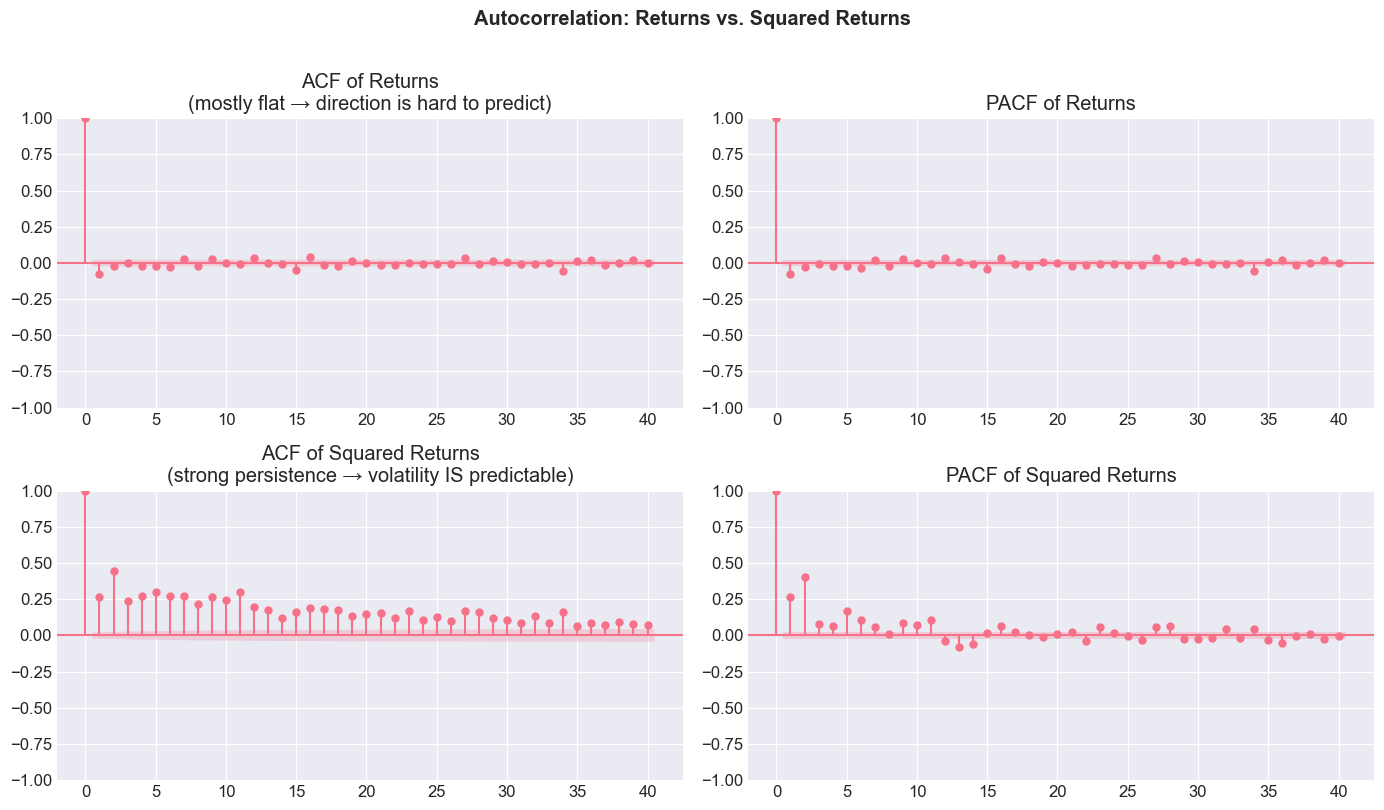

Ljung-Box test on squared returns (p near 0 = strong autocorrelation in variance):
        lb_stat  lb_pvalue
10  6377.662783        0.0
20  9068.483574        0.0

Conclusion: Volatility has memory. GARCH is the right tool to capture it.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(returns,     lags=40, ax=axes[0,0],
         title='ACF of Returns\n(mostly flat → direction is hard to predict)')
plot_pacf(returns,    lags=40, ax=axes[0,1],
         title='PACF of Returns', method='ywm')
plot_acf(returns**2,  lags=40, ax=axes[1,0],
         title='ACF of Squared Returns\n(strong persistence → volatility IS predictable)')
plot_pacf(returns**2, lags=40, ax=axes[1,1],
         title='PACF of Squared Returns', method='ywm')

plt.suptitle('Autocorrelation: Returns vs. Squared Returns', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(returns**2, lags=[10, 20], return_df=True)
print('Ljung-Box test on squared returns (p near 0 = strong autocorrelation in variance):')
print(lb.to_string())
print('\nConclusion: Volatility has memory. GARCH is the right tool to capture it.')

### 4.4 VIX vs. Realised Volatility — The Variance Risk Premium

Implied volatility (VIX) consistently exceeds realized volatility over the same horizon. Over the full sample, VIX exceeded 21-day realized volatility on **85.3% of trading days**, with an average premium of **3.67 annualized volatility points**. This gap — the **variance risk premium** — reflects compensation demanded by options sellers for bearing convex volatility exposure. It is persistent, well-documented, and rational: sellers require a premium precisely because volatility can spike sharply and suddenly.

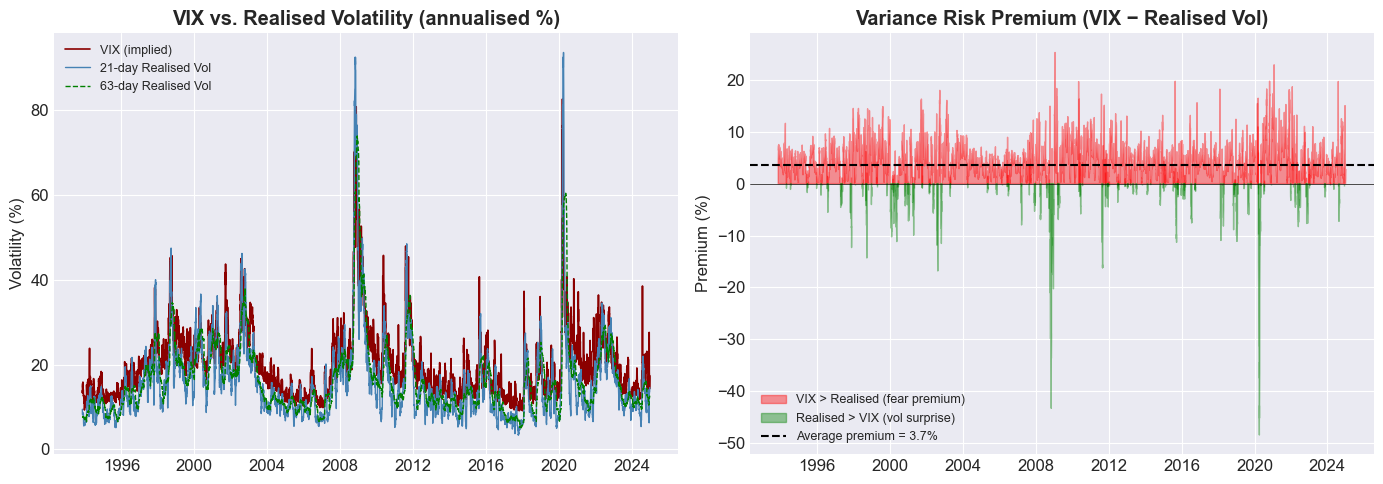

VIX exceeded Realised Vol on 85.3% of all trading days
Average premium: 3.67% annualised


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(spy_aligned.index, fred_aligned['VIX']  * 100, label='VIX (implied)',       color='darkred',   linewidth=1.2)
ax.plot(spy_aligned.index, spy_aligned['RV_21'] * 100, label='21-day Realised Vol', color='steelblue', linewidth=1.0)
ax.plot(spy_aligned.index, spy_aligned['RV_63'] * 100, label='63-day Realised Vol', color='green',     linewidth=1.0, linestyle='--')
ax.set_title('VIX vs. Realised Volatility (annualised %)', fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=9)

ax = axes[1]
vrp = (fred_aligned['VIX'] - spy_aligned['RV_21']) * 100
ax.fill_between(vrp.index, vrp, 0, where=(vrp >= 0), alpha=0.4, color='red',   label='VIX > Realised (fear premium)')
ax.fill_between(vrp.index, vrp, 0, where=(vrp <  0), alpha=0.4, color='green', label='Realised > VIX (vol surprise)')
ax.axhline(vrp.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Average premium = {vrp.mean():.1f}%')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Variance Risk Premium (VIX − Realised Vol)', fontweight='bold')
ax.set_ylabel('Premium (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_variance_risk_premium.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'VIX exceeded Realised Vol on {(vrp > 0).mean():.1%} of all trading days')
print(f'Average premium: {vrp.mean():.2f}% annualised')

### 4.5 VIX Term Structure — Short-Term vs. Long-Term Implied Volatility

Under normal market conditions, longer-dated implied volatility exceeds near-term implied volatility, a state of **contango** reflecting greater uncertainty at longer horizons. During acute stress, short-term fear can spike sharply enough to invert this relationship, with VIX rising above VIX3M. Over the full sample, the term structure inverted on **10.1% of trading days**, with inversions concentrated around the 2008 financial crisis, the 2020 COVID shock, and the 2022 rate-hiking cycle, distinguishing acute panic from prolonged but orderly uncertainty.

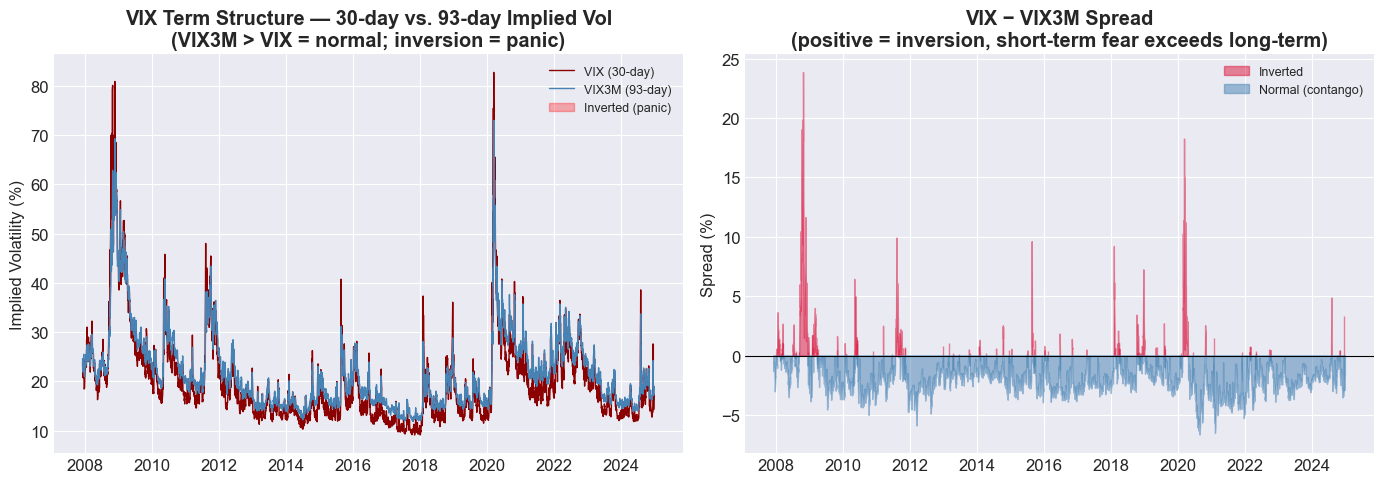

Term structure inverted on 10.1% of trading days
Average spread: -1.68%  (negative = normal, VIX3M usually higher than VIX)


In [8]:
term_df = fred_data[['VIX', 'VIX3M']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(term_df.index, term_df['VIX']   * 100, label='VIX (30-day)',   color='darkred',  linewidth=1)
ax.plot(term_df.index, term_df['VIX3M'] * 100, label='VIX3M (93-day)', color='steelblue', linewidth=1)
ax.fill_between(term_df.index,
                term_df['VIX'] * 100, term_df['VIX3M'] * 100,
                where=(term_df['VIX'] > term_df['VIX3M']),
                alpha=0.3, color='red', label='Inverted (panic)')
ax.set_title('VIX Term Structure — 30-day vs. 93-day Implied Vol\n(VIX3M > VIX = normal; inversion = panic)', fontweight='bold')
ax.set_ylabel('Implied Volatility (%)')
ax.legend(fontsize=9)

ax = axes[1]
spread = (term_df['VIX'] - term_df['VIX3M']) * 100
ax.fill_between(spread.index, spread, 0, where=(spread >= 0), alpha=0.5, color='crimson',   label='Inverted')
ax.fill_between(spread.index, spread, 0, where=(spread <  0), alpha=0.5, color='steelblue', label='Normal (contango)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('VIX − VIX3M Spread\n(positive = inversion, short-term fear exceeds long-term)', fontweight='bold')
ax.set_ylabel('Spread (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_vix_term_structure.png', dpi=150, bbox_inches='tight')
plt.show()

inversion_pct = (spread > 0).mean()
print(f'Term structure inverted on {inversion_pct:.1%} of trading days')
print(f'Average spread: {spread.mean():.2f}%  (negative = normal, VIX3M usually higher than VIX)')

## 5. GARCH & GJR-GARCH Volatility Modeling

### What GARCH does

GARCH(1,1) models today's conditional variance ($\sigma_t^2$) as a weighted sum of three components:
1. A long-run average variance ($\omega$)
2. The squared return shock from the prior period ($\alpha \cdot \epsilon_{t-1}^2$) — sensitivity to recent shocks
3. The prior period's variance estimate ($\beta \cdot \sigma_{t-1}^2$) — persistence of elevated volatility

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

**GJR-GARCH** extends this with an asymmetric term ($\gamma$) that applies additional weight to negative return shocks, capturing the **leverage effect**: negative innovations raise conditional variance by more than positive shocks of equal magnitude.

$$\sigma_t^2 = \omega + (\alpha + \gamma \cdot \mathbb{1}_{\epsilon_{t-1}<0})\epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

### 5.1 Fit Both Models

In [9]:
returns_pct = returns * 100   # scale to % for numerical stability

garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1,    dist='normal')
garch_fit   = garch_model.fit(disp='off')

gjr_model   = arch_model(returns_pct, vol='Garch', p=1, o=1, q=1, dist='normal')  # o=1 adds leverage term
gjr_fit     = gjr_model.fit(disp='off')

# Convert conditional vol back to annualised decimal
garch_vol = (garch_fit.conditional_volatility / 100 * np.sqrt(252)).rename('GARCH')
gjr_vol   = (gjr_fit.conditional_volatility   / 100 * np.sqrt(252)).rename('GJR-GARCH')
garch_vol.index = spy.index[:len(garch_vol)]
gjr_vol.index   = spy.index[:len(gjr_vol)]

alpha_g  = garch_fit.params['alpha[1]']
beta_g   = garch_fit.params['beta[1]']
alpha_gj = gjr_fit.params['alpha[1]']
gamma_gj = gjr_fit.params['gamma[1]']
beta_gj  = gjr_fit.params['beta[1]']

print('=== GARCH(1,1) ===')
print(f'  Alpha  (how fast vol reacts to shocks):  {alpha_g:.4f}')
print(f'  Beta   (how long vol stays elevated):    {beta_g:.4f}')
print(f'  Alpha + Beta:                            {alpha_g+beta_g:.4f}  (close to 1 = very persistent)')
print(f'  Half-life of a vol spike:                {np.log(0.5)/np.log(alpha_g+beta_g):.1f} trading days')
print(f'  AIC: {garch_fit.aic:.1f}')

print('\n=== GJR-GARCH(1,1) ===')
print(f'  Alpha  (positive shock impact):          {alpha_gj:.4f}')
print(f'  Gamma  (extra impact of negative shocks):{gamma_gj:.4f}  ← the leverage effect')
print(f'  Beta   (persistence):                    {beta_gj:.4f}')
print(f'  Effective impact of bad news:            {alpha_gj+gamma_gj:.4f}  (vs {alpha_gj:.4f} for good news)')
print(f'  AIC: {gjr_fit.aic:.1f}')
print(f'\nAIC improvement (lower is better): {garch_fit.aic - gjr_fit.aic:.1f} points → GJR-GARCH is a better fit')

=== GARCH(1,1) ===
  Alpha  (how fast vol reacts to shocks):  0.1167
  Beta   (how long vol stays elevated):    0.8677
  Alpha + Beta:                            0.9845  (close to 1 = very persistent)
  Half-life of a vol spike:                44.3 trading days
  AIC: 21384.8

=== GJR-GARCH(1,1) ===
  Alpha  (positive shock impact):          0.0065
  Gamma  (extra impact of negative shocks):0.1727  ← the leverage effect
  Beta   (persistence):                    0.8853
  Effective impact of bad news:            0.1793  (vs 0.0065 for good news)
  AIC: 21128.1

AIC improvement (lower is better): 256.7 points → GJR-GARCH is a better fit


### 5.2 GARCH vs. GJR-GARCH — Does the Leverage Effect Matter?

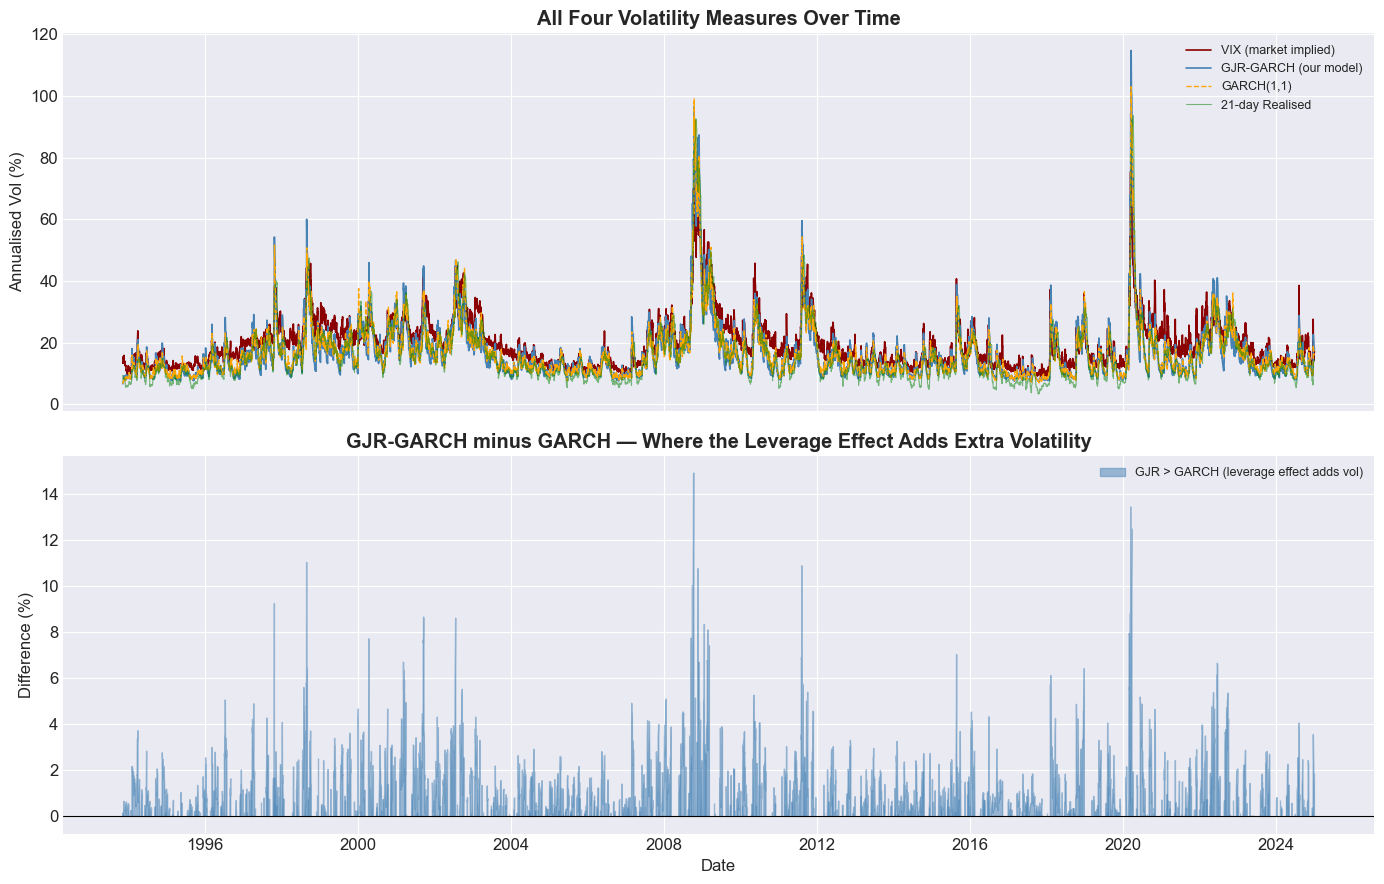

Correlation between all four volatility measures:
           GARCH  GJR-GARCH    VIX  RV_21
GARCH      1.000      0.970  0.880  0.961
GJR-GARCH  0.970      1.000  0.877  0.919
VIX        0.880      0.877  1.000  0.873
RV_21      0.961      0.919  0.873  1.000


In [10]:
common_vol = garch_vol.index.intersection(gjr_vol.index).intersection(spy_aligned.index)

df_vol = pd.DataFrame({
    'GARCH'     : garch_vol.loc[common_vol],
    'GJR-GARCH' : gjr_vol.loc[common_vol],
    'VIX'       : fred_aligned.loc[common_vol, 'VIX'],
    'RV_21'     : spy_aligned.loc[common_vol, 'RV_21']
})

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(df_vol.index, df_vol['VIX']       * 100, label='VIX (market implied)',  color='darkred',   linewidth=1.2)
ax.plot(df_vol.index, df_vol['GJR-GARCH'] * 100, label='GJR-GARCH (our model)', color='steelblue', linewidth=1.2)
ax.plot(df_vol.index, df_vol['GARCH']     * 100, label='GARCH(1,1)',             color='orange',    linewidth=1.0, linestyle='--')
ax.plot(df_vol.index, df_vol['RV_21']     * 100, label='21-day Realised',        color='green',     linewidth=0.8, alpha=0.5)
ax.set_title('All Four Volatility Measures Over Time', fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.legend(fontsize=9)

ax = axes[1]
diff = (df_vol['GJR-GARCH'] - df_vol['GARCH']) * 100
ax.fill_between(diff.index, diff, 0, where=(diff >= 0),
                alpha=0.5, color='steelblue', label='GJR > GARCH (leverage effect adds vol)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('GJR-GARCH minus GARCH — Where the Leverage Effect Adds Extra Volatility', fontweight='bold')
ax.set_ylabel('Difference (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig6_garch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation between all four volatility measures:')
print(df_vol.corr().round(3))

### 5.3 Model Diagnostics

After fitting GJR-GARCH, we examine the standardised residuals, the portion of each day's return unexplained by the model. A well-specified model should produce residuals indistinguishable from white noise. The Ljung-Box test on squared standardised residuals returns p = 0.257, confirming no remaining autocorrelation in variance, the model has fully captured the volatility dynamics.

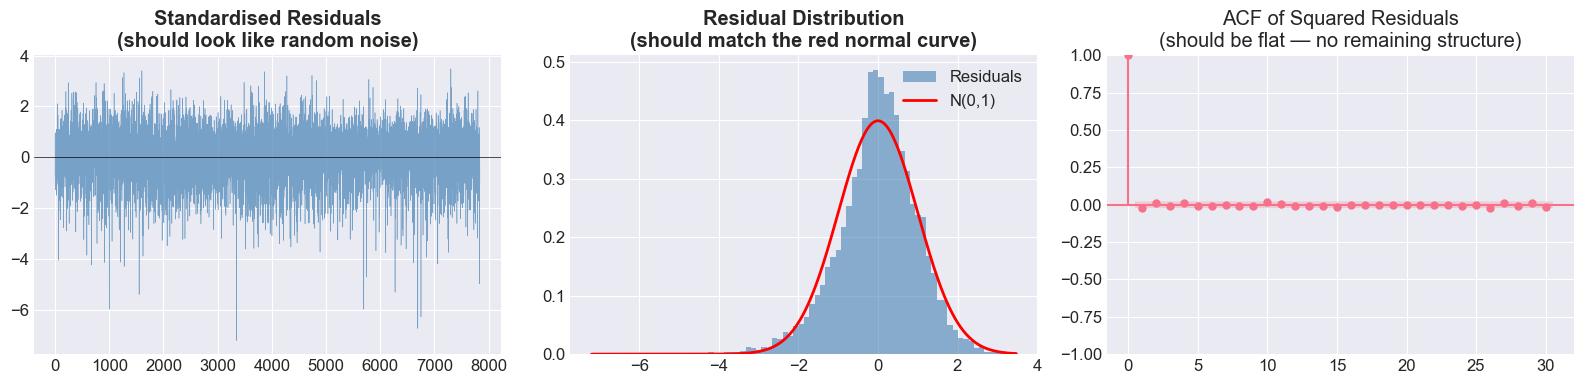

Ljung-Box test on squared standardised residuals (p > 0.05 = residuals are white noise):
      lb_stat  lb_pvalue
10  12.435742   0.256952


In [11]:
std_resid = gjr_fit.std_resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(std_resid.values, linewidth=0.4, alpha=0.7, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Standardised Residuals\n(should look like random noise)', fontweight='bold')

ax = axes[1]
ax.hist(std_resid, bins=80, density=True, alpha=0.6, color='steelblue', label='Residuals')
x = np.linspace(std_resid.min(), std_resid.max(), 300)
ax.plot(x, norm.pdf(x, 0, 1), 'r-', linewidth=2, label='N(0,1)')
ax.set_title('Residual Distribution\n(should match the red normal curve)', fontweight='bold')
ax.legend()

plot_acf(std_resid**2, lags=30, ax=axes[2],
         title='ACF of Squared Residuals\n(should be flat — no remaining structure)')

plt.tight_layout()
plt.savefig('fig7_gjr_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
print('Ljung-Box test on squared standardised residuals (p > 0.05 = residuals are white noise):')
print(lb.to_string())

### 5.4 30-Day Volatility Forecast

While price direction is difficult to predict, the *level* of volatility over coming weeks is genuinely forecastable. GARCH forecasts mean-revert toward the long-run average: from the current estimate of **18.23%**, the model projects **19.07%** on day 1, declining to **17.84%** by day 30, converging toward the long-run mean of **16.40%**.

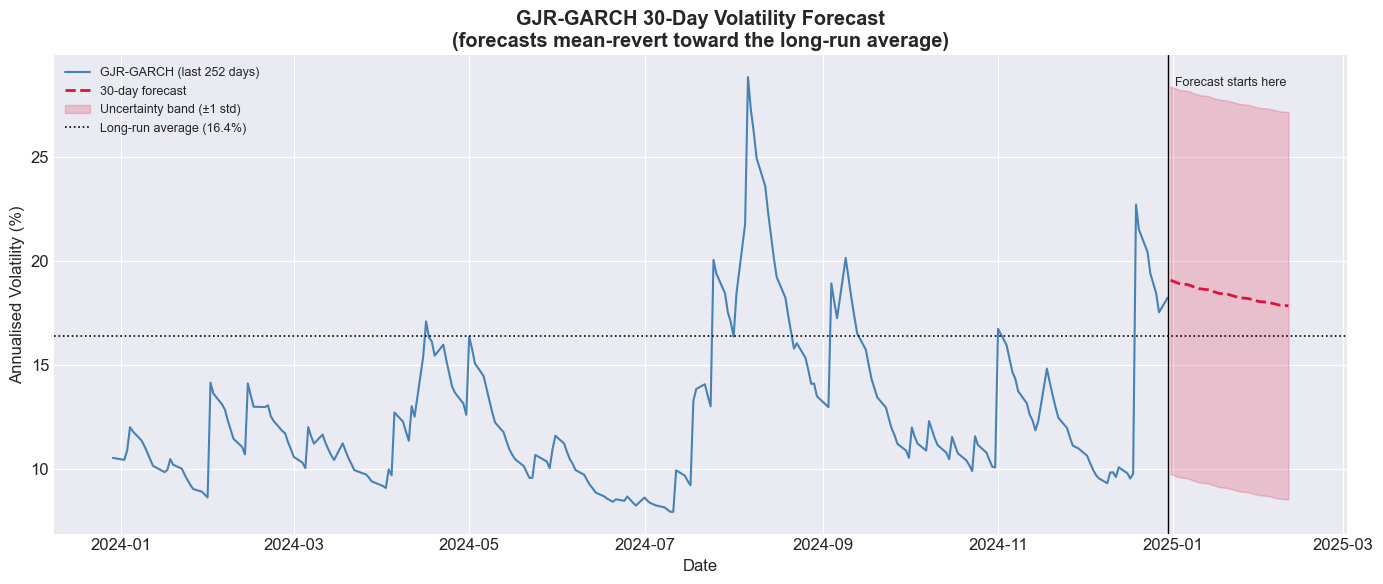

Current vol estimate (last observed day): 18.23%
Forecast — Day 1:  19.07%
Forecast — Day 30: 17.84%
Long-run mean:     16.40%


In [12]:
HORIZON = 30

forecasts    = gjr_fit.forecast(horizon=HORIZON, reindex=False)
var_forecast = forecasts.variance.values[-1]               # shape (30,)
vol_forecast = np.sqrt(var_forecast) / 100 * np.sqrt(252)  # annualised decimal

last_date      = gjr_vol.index[-1]
forecast_dates = pd.bdate_range(start=last_date, periods=HORIZON + 1)[1:]
long_run_vol   = gjr_vol.values.mean()
vol_std        = gjr_vol.values.std()

fig, ax = plt.subplots(figsize=(14, 6))

recent = gjr_vol.iloc[-252:]
ax.plot(recent.index, recent * 100, color='steelblue', linewidth=1.5, label='GJR-GARCH (last 252 days)')
ax.plot(forecast_dates, vol_forecast * 100, color='crimson', linewidth=2,
        linestyle='--', label='30-day forecast')
ax.fill_between(forecast_dates,
                (vol_forecast - vol_std) * 100,
                (vol_forecast + vol_std) * 100,
                alpha=0.2, color='crimson', label='Uncertainty band (±1 std)')
ax.axhline(long_run_vol * 100, color='black', linestyle=':', linewidth=1.2,
           label=f'Long-run average ({long_run_vol:.1%})')
ax.axvline(last_date, color='black', linewidth=1)
ax.text(last_date, ax.get_ylim()[1] * 0.95, '  Forecast starts here', fontsize=9)
ax.set_title('GJR-GARCH 30-Day Volatility Forecast\n(forecasts mean-revert toward the long-run average)', fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig8_garch_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Current vol estimate (last observed day): {gjr_vol.iloc[-1]:.2%}')
print(f'Forecast — Day 1:  {vol_forecast[0]:.2%}')
print(f'Forecast — Day 30: {vol_forecast[-1]:.2%}')
print(f'Long-run mean:     {long_run_vol:.2%}')

## 6. Multi-Asset Volatility Analysis

We fit GJR-GARCH separately to **SPY** (broad market), **QQQ** (technology), and **GLD** (gold) to examine two questions:
1. Do different asset classes exhibit different volatility dynamics?
2. Does volatility co-move across asset classes during periods of market stress?

In [13]:
asset_vols = {}
asset_fits = {}

for ticker in TICKERS:
    prices = multi_close[ticker].dropna()
    rets   = np.log(prices / prices.shift(1)).dropna() * 100

    model  = arch_model(rets, vol='Garch', p=1, o=1, q=1, dist='normal')
    fitted = model.fit(disp='off')
    asset_fits[ticker] = fitted

    vol = fitted.conditional_volatility / 100 * np.sqrt(252)
    vol.index = prices.index[:len(vol)]
    asset_vols[ticker] = vol

    a = fitted.params['alpha[1]']
    g = fitted.params['gamma[1]']
    b = fitted.params['beta[1]']
    hl = np.log(0.5) / np.log(a + g/2 + b)
    print(f'{ticker}: alpha={a:.3f}, gamma={g:.3f}, beta={b:.3f}, '
          f'half-life≈{hl:.0f}d, mean vol={vol.mean():.1%}')

vol_df = pd.DataFrame(asset_vols).dropna()

SPY: alpha=0.011, gamma=0.201, beta=0.861, half-life≈24d, mean vol=16.0%
QQQ: alpha=0.007, gamma=0.159, beta=0.885, half-life≈24d, mean vol=19.3%
GLD: alpha=0.064, gamma=-0.023, beta=0.939, half-life≈84d, mean vol=16.6%


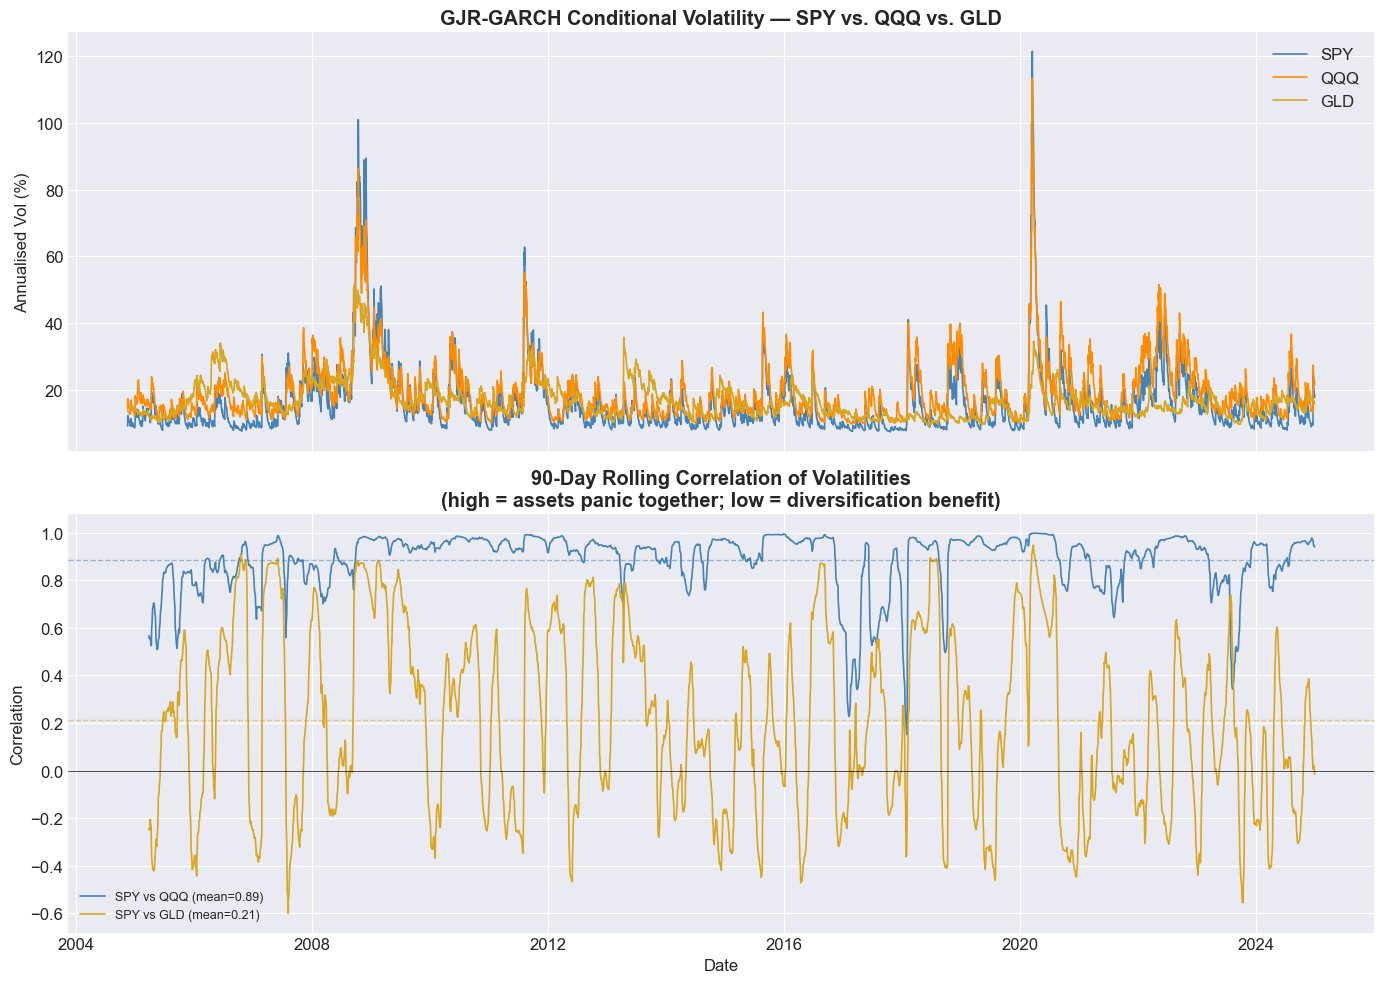

Full-period volatility correlation matrix:
       SPY    QQQ    GLD
SPY  1.000  0.952  0.577
QQQ  0.952  1.000  0.513
GLD  0.577  0.513  1.000

Average annualised vol: SPY=16.0%, QQQ=19.3%, GLD=16.6%


In [14]:
ticker_colors = {'SPY': 'steelblue', 'QQQ': 'darkorange', 'GLD': 'goldenrod'}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
for ticker, color in ticker_colors.items():
    ax.plot(vol_df.index, vol_df[ticker] * 100, label=ticker, color=color, linewidth=1.2)
ax.set_title('GJR-GARCH Conditional Volatility — SPY vs. QQQ vs. GLD', fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.legend()

ax = axes[1]
roll_spy_qqq = vol_df['SPY'].rolling(90).corr(vol_df['QQQ'])
roll_spy_gld = vol_df['SPY'].rolling(90).corr(vol_df['GLD'])
ax.plot(vol_df.index, roll_spy_qqq, label=f'SPY vs QQQ (mean={roll_spy_qqq.mean():.2f})',
        color='steelblue', linewidth=1.2)
ax.plot(vol_df.index, roll_spy_gld, label=f'SPY vs GLD (mean={roll_spy_gld.mean():.2f})',
        color='goldenrod', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(roll_spy_qqq.mean(), color='steelblue', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(roll_spy_gld.mean(), color='goldenrod', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('90-Day Rolling Correlation of Volatilities\n(high = assets panic together; low = diversification benefit)', fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig9_multi_asset_garch.png', dpi=150, bbox_inches='tight')
plt.show()

print('Full-period volatility correlation matrix:')
print(vol_df.corr().round(3))
print(f'\nAverage annualised vol: SPY={vol_df["SPY"].mean():.1%}, '
      f'QQQ={vol_df["QQQ"].mean():.1%}, GLD={vol_df["GLD"].mean():.1%}')

## 7. Volatility Regime Classification

We classify every trading day into one of four regimes based on GJR-GARCH conditional volatility, with thresholds set at the 25th, 75th, and 95th percentiles of the full SPY volatility history: **Low** (< 10.5%), **Medium** (10.5–19.2%), **High** (19.2–31.9%), and **Extreme** (> 31.9%).

Regime thresholds (annualised vol):
  Low    : < 10.5%
  Medium : 10.5% – 19.2%
  High   : 19.2% – 31.9%
  Extreme: > 31.9%


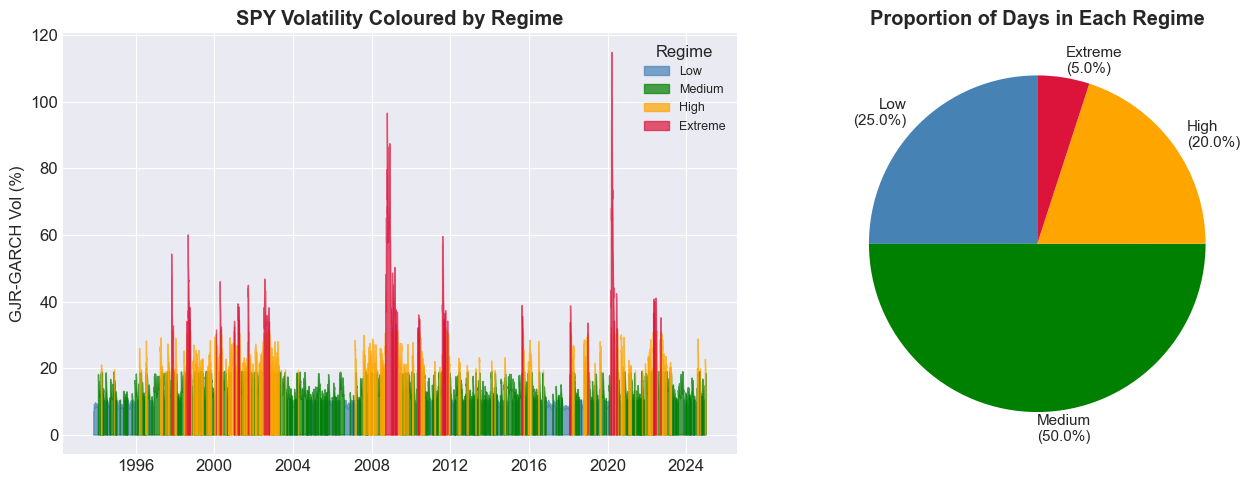

In [15]:
gjr_spy = gjr_vol.loc[common_vol]

q25 = gjr_spy.quantile(0.25)
q75 = gjr_spy.quantile(0.75)
q95 = gjr_spy.quantile(0.95)

def classify(v):
    if v <= q25: return 'Low'
    if v <= q75: return 'Medium'
    if v <= q95: return 'High'
    return 'Extreme'

regime        = gjr_spy.apply(classify)
regime_order  = ['Low', 'Medium', 'High', 'Extreme']
regime_colors = {'Low': 'steelblue', 'Medium': 'green', 'High': 'orange', 'Extreme': 'crimson'}

print(f'Regime thresholds (annualised vol):')
print(f'  Low    : < {q25:.1%}')
print(f'  Medium : {q25:.1%} – {q75:.1%}')
print(f'  High   : {q75:.1%} – {q95:.1%}')
print(f'  Extreme: > {q95:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for r, color in regime_colors.items():
    mask = (regime == r).values
    ax.fill_between(gjr_spy.index, 0, gjr_spy * 100, where=mask, alpha=0.7, color=color, label=r)
ax.set_title('SPY Volatility Coloured by Regime', fontweight='bold')
ax.set_ylabel('GJR-GARCH Vol (%)')
ax.legend(title='Regime', fontsize=9)

ax = axes[1]
counts = regime.value_counts().reindex(regime_order)
ax.pie(counts.values,
       labels=[f'{r}\n({c/len(regime):.1%})' for r, c in zip(counts.index, counts.values)],
       colors=[regime_colors[r] for r in counts.index],
       startangle=90, textprops={'fontsize': 11})
ax.set_title('Proportion of Days in Each Regime', fontweight='bold')

plt.tight_layout()
plt.savefig('fig10_volatility_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Black-Scholes Pricing Across Volatility Regimes

We price a **30-day at-the-money call option** on SPY every trading day using three volatility inputs and the actual daily T-bill rate from FRED, then measure how prices diverge across models and regimes.

The analysis has two extensions:
1. **Forecast accuracy** (Section 8.3): Which volatility measure — constant, GJR-GARCH, or VIX — best predicts realized volatility over the following 21 trading days?
2. **Heston model** (Section 8.4): We price the same option under Heston (1993), which treats volatility as a stochastic process rather than a fixed input, and compare it against all three Black-Scholes variants.

In [16]:
def black_scholes_call(S, K, T, r, sigma):
    """Black-Scholes call price.
    S=spot, K=strike, T=years to expiry, r=risk-free rate, sigma=annualised vol.
    """
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return float(S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))

T        = 30 / 252
hist_vol = returns.std() * np.sqrt(252)  # constant vol baseline

spot   = spy_aligned.loc[common_vol, 'Close']
tbill  = fred_aligned.loc[common_vol, 'TBILL'].ffill()
vix_s  = fred_aligned.loc[common_vol, 'VIX']
gjr_s  = gjr_spy.loc[common_vol]

pricing = pd.DataFrame(index=common_vol)
pricing['Spot']   = spot.values
pricing['TBill']  = tbill.values
pricing['Regime'] = regime.loc[common_vol].values

pricing['BS_Const'] = [
    black_scholes_call(s, s, T, r, hist_vol)
    for s, r in zip(pricing['Spot'], pricing['TBill'])
]
pricing['BS_GJR'] = [
    black_scholes_call(s, s, T, r, max(g, 0.001))
    for s, r, g in zip(pricing['Spot'], pricing['TBill'], gjr_s)
]
pricing['BS_VIX'] = [
    black_scholes_call(s, s, T, r, v)
    for s, r, v in zip(pricing['Spot'], pricing['TBill'], vix_s)
]

for col in ['BS_Const', 'BS_GJR', 'BS_VIX']:
    pricing[f'{col}_pct'] = pricing[col] / pricing['Spot'] * 100

pricing['GJR_vs_Const'] = pricing['BS_GJR_pct'] - pricing['BS_Const_pct']
pricing['VIX_vs_Const'] = pricing['BS_VIX_pct'] - pricing['BS_Const_pct']

print(f'Constant vol baseline: {hist_vol:.2%}')
print(f'\nATM call price (% of spot) — summary by method:')
print(pricing[['BS_Const_pct','BS_GJR_pct','BS_VIX_pct']].describe().round(3))

Constant vol baseline: 18.80%

ATM call price (% of spot) — summary by method:
       BS_Const_pct  BS_GJR_pct  BS_VIX_pct
count      7838.000    7838.000    7838.000
mean          2.730       2.402       2.856
std           0.127       1.267       1.099
min           2.584       1.070       1.327
25%           2.595       1.603       2.074
50%           2.691       2.063       2.593
75%           2.872       2.796       3.361
max           2.964      15.707      11.356


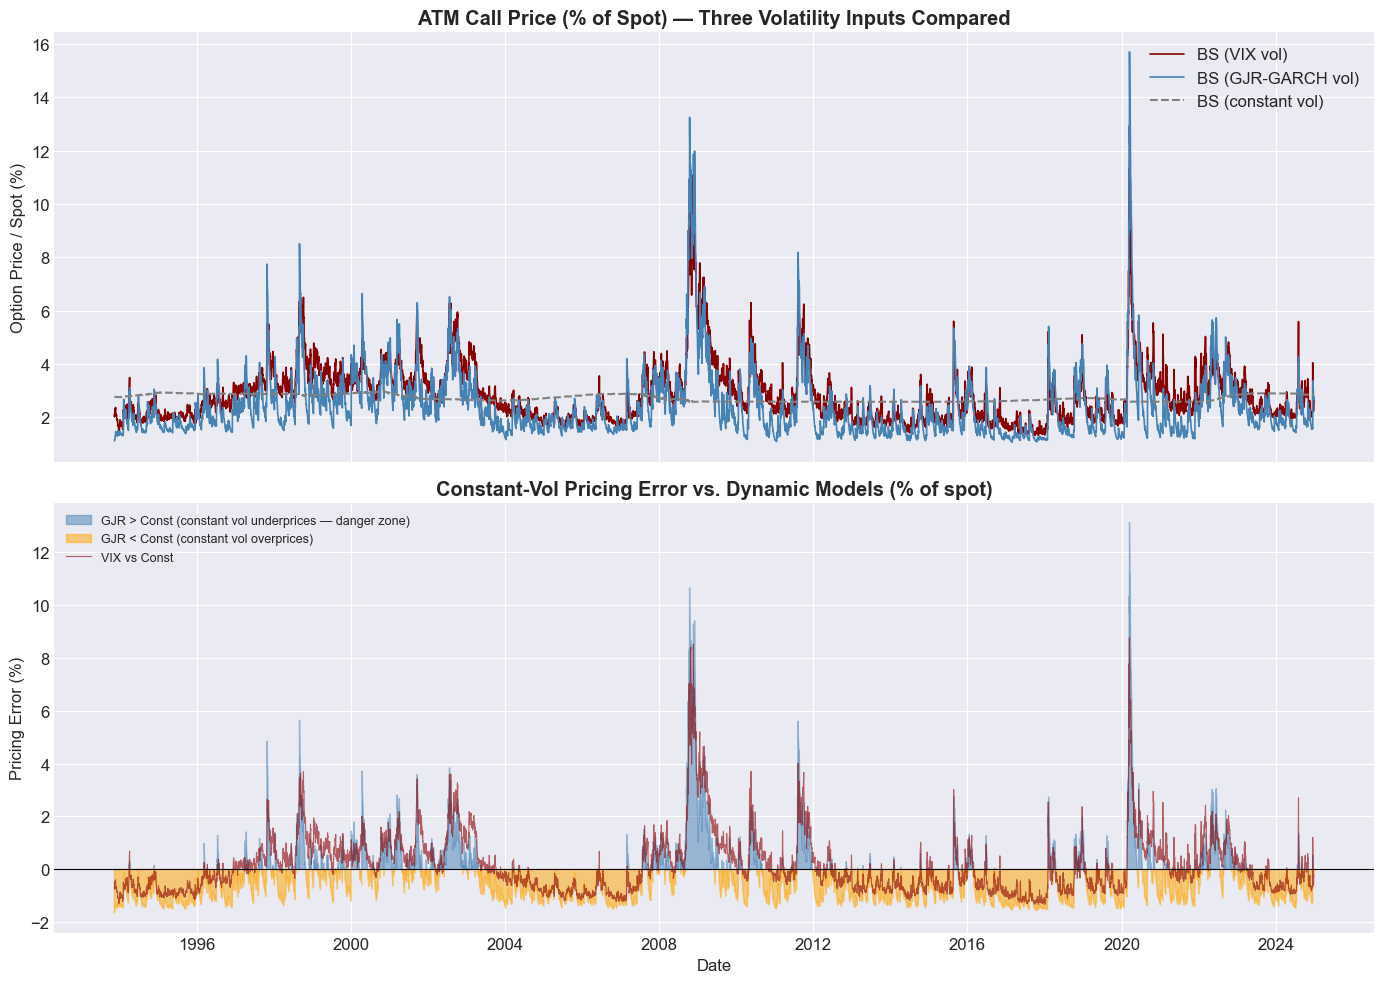

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.plot(pricing.index, pricing['BS_VIX_pct'],   label='BS (VIX vol)',       color='darkred',   linewidth=1.2)
ax.plot(pricing.index, pricing['BS_GJR_pct'],   label='BS (GJR-GARCH vol)', color='steelblue', linewidth=1.2)
ax.plot(pricing.index, pricing['BS_Const_pct'], label='BS (constant vol)',   color='grey',      linewidth=1.5, linestyle='--')
ax.set_title('ATM Call Price (% of Spot) — Three Volatility Inputs Compared', fontweight='bold')
ax.set_ylabel('Option Price / Spot (%)')
ax.legend()

ax = axes[1]
ax.fill_between(pricing.index, pricing['GJR_vs_Const'], 0,
                where=(pricing['GJR_vs_Const'] > 0), alpha=0.5, color='steelblue',
                label='GJR > Const (constant vol underprices — danger zone)')
ax.fill_between(pricing.index, pricing['GJR_vs_Const'], 0,
                where=(pricing['GJR_vs_Const'] < 0), alpha=0.5, color='orange',
                label='GJR < Const (constant vol overprices)')
ax.plot(pricing.index, pricing['VIX_vs_Const'],
        color='darkred', linewidth=0.8, alpha=0.6, label='VIX vs Const')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Constant-Vol Pricing Error vs. Dynamic Models (% of spot)', fontweight='bold')
ax.set_ylabel('Pricing Error (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig11_bs_pricing.png', dpi=150, bbox_inches='tight')
plt.show()

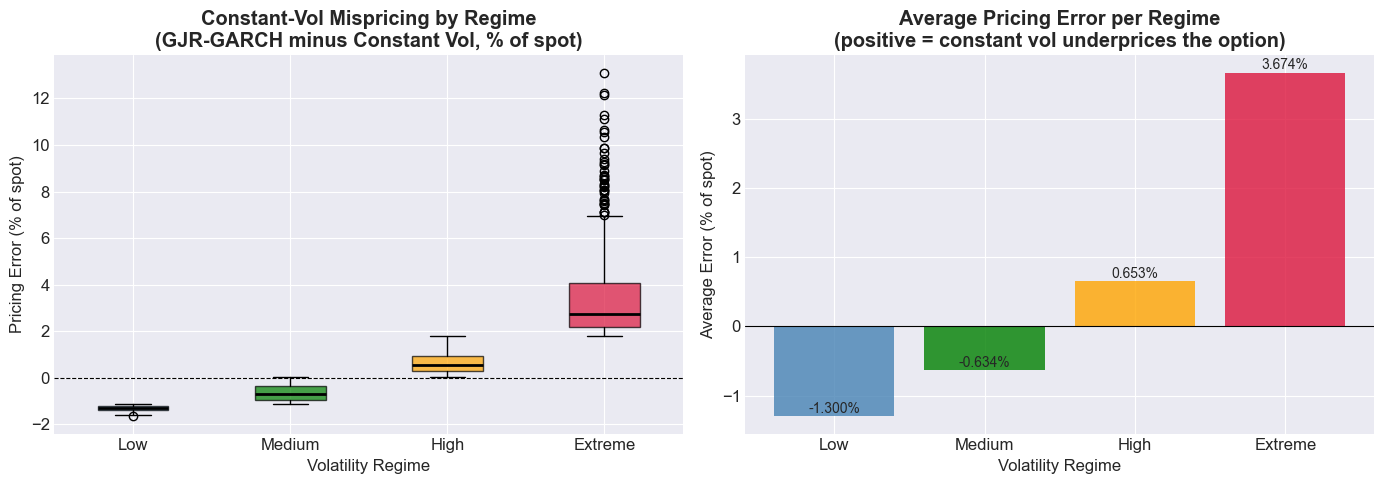

Detailed mispricing stats by regime:
  Low     : mean=-1.3003%  max=-1.1238%  min=-1.6521%  n=1960
  Medium  : mean=-0.6338%  max=0.0493%  min=-1.1360%  n=3918
  High    : mean=0.6526%  max=1.7968%  min=0.0531%  n=1568
  Extreme : mean=3.6736%  max=13.1097%  min=1.7886%  n=392


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Box plot of mispricing by regime
ax = axes[0]
groups = [pricing.loc[pricing['Regime'] == r, 'GJR_vs_Const'] for r in regime_order]
bp = ax.boxplot(groups, labels=regime_order, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, r in zip(bp['boxes'], regime_order):
    patch.set_facecolor(regime_colors[r])
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Constant-Vol Mispricing by Regime\n(GJR-GARCH minus Constant Vol, % of spot)', fontweight='bold')
ax.set_xlabel('Volatility Regime')
ax.set_ylabel('Pricing Error (% of spot)')

# — Mean mispricing bar chart
ax = axes[1]
means = pricing.groupby('Regime')['GJR_vs_Const'].mean().reindex(regime_order)
bars  = ax.bar(regime_order, means.values, color=[regime_colors[r] for r in regime_order], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.002 * np.sign(val) if val != 0 else 0.002,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Average Pricing Error per Regime\n(positive = constant vol underprices the option)', fontweight='bold')
ax.set_xlabel('Volatility Regime')
ax.set_ylabel('Average Error (% of spot)')

plt.tight_layout()
plt.savefig('fig12_mispricing_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

print('Detailed mispricing stats by regime:')
for r in regime_order:
    sub = pricing.loc[pricing['Regime'] == r, 'GJR_vs_Const']
    print(f'  {r:8s}: mean={sub.mean():.4f}%  max={sub.max():.4f}%  min={sub.min():.4f}%  n={len(sub)}')

### 8.3 Forecast Accuracy: Which Volatility Estimate Best Predicts Realized Vol?

A volatility model's practical value depends on how well it predicts future realized volatility. We test this directly: for each day in the sample, we compare each model's current estimate against **realized volatility over the following 21 trading days**. Lower RMSE and MAE indicate better forecast accuracy; bias measures systematic over- or under-estimation.

| Model | What it captures |
|---|---|
| Constant Vol | Long-run unconditional average — ignores current market conditions |
| GJR-GARCH | Updates daily from recent returns; captures clustering and the leverage effect |
| VIX | Market consensus — aggregates the expectations of all options market participants |

Forecast Accuracy: Predicting 21-Day Realized Volatility
(Positive bias = model tends to OVERestimate future vol)

  Constant Vol          RMSE=10.39%  MAE=7.64%  Bias=+2.74%
  GJR-GARCH             RMSE=7.67%  MAE=4.87%  Bias=+0.35%
  VIX (Implied)         RMSE=7.90%  MAE=5.86%  Bias=+3.66%


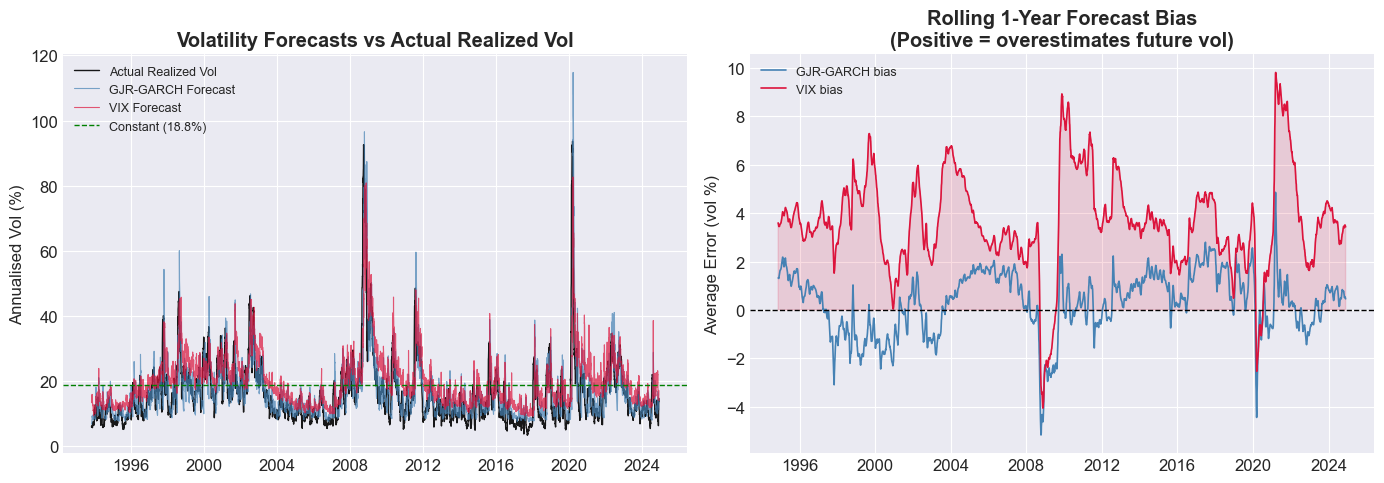

In [19]:
# Shift RV_21 forward 21 days: future_rv[t] = realized vol over next 21 days
future_rv  = spy_aligned['RV_21'].shift(-21)
vix_pred   = fred_aligned['VIX']          # already decimal from clean_fred()
garch_pred = gjr_vol
const_pred = returns.std() * np.sqrt(252)

idx = (vix_pred.dropna().index
       .intersection(garch_pred.dropna().index)
       .intersection(future_rv.dropna().index))

fv   = future_rv.loc[idx]
vix_ = vix_pred.loc[idx]
gjr_ = garch_pred.loc[idx]
con_ = pd.Series(const_pred, index=idx)

def rmse(a, b): return np.sqrt(((a - b) ** 2).mean())
def mae(a, b):  return (a - b).abs().mean()

print("Forecast Accuracy: Predicting 21-Day Realized Volatility")
print("(Positive bias = model tends to OVERestimate future vol)\n")
for name, pred in [("Constant Vol", con_), ("GJR-GARCH", gjr_), ("VIX (Implied)", vix_)]:
    print(f"  {name:20s}  RMSE={rmse(pred,fv):.2%}  MAE={mae(pred,fv):.2%}  Bias={(pred-fv).mean():+.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fv.index,   fv   * 100, label='Actual Realized Vol', color='black',     lw=1,   alpha=0.9)
ax.plot(gjr_.index, gjr_ * 100, label='GJR-GARCH Forecast',  color='steelblue', lw=0.8, alpha=0.7)
ax.plot(vix_.index, vix_ * 100, label='VIX Forecast',         color='crimson',   lw=0.8, alpha=0.7)
ax.axhline(const_pred * 100, color='green', ls='--', lw=1, label=f'Constant ({const_pred:.1%})')
ax.set_title('Volatility Forecasts vs Actual Realized Vol', fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.legend(fontsize=9)

ax = axes[1]
bias_gjr = (gjr_ - fv).rolling(252).mean() * 100
bias_vix = (vix_ - fv).rolling(252).mean() * 100
ax.plot(bias_gjr.index, bias_gjr, label='GJR-GARCH bias', color='steelblue', lw=1.2)
ax.plot(bias_vix.index, bias_vix, label='VIX bias',        color='crimson',   lw=1.2)
ax.axhline(0, color='black', ls='--', lw=1)
ax.fill_between(bias_vix.index, 0, bias_vix,
                where=(bias_vix > 0), alpha=0.15, color='crimson')
ax.set_title('Rolling 1-Year Forecast Bias\n(Positive = overestimates future vol)', fontweight='bold')
ax.set_ylabel('Average Error (vol %)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig13_forecast_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.4 The Heston Model: Stochastic Volatility

Every Black-Scholes variant prices options by taking a single volatility number as input. The Heston (1993) model resolves this by treating variance as its own stochastic process, evolving jointly with the stock price:

**Stock:**&nbsp;&nbsp;&nbsp;&nbsp;$dS = \mu S\, dt + \sqrt{v}\, S\, dW_S$
**Variance:** $dv = \kappa(\theta - v)\, dt + \sigma_v \sqrt{v}\, dW_v$

| Parameter | Meaning | Value Used |
|---|---|---|
| κ (kappa) | Mean reversion speed | 2.0 (~125-day half-life) |
| θ (theta) | Long-run average variance | Long-run VIX² from data |
| σᵥ (vol-of-vol) | Volatility of the variance process | 0.30 |
| ρ (rho) | Stock–volatility shock correlation | −0.70 |

The negative correlation (ρ = −0.70) directly encodes the leverage effect measured in Section 5: stock declines coincide with variance increases. Black-Scholes has no mechanism to represent this relationship. We initialize v₀ = VIX² each month so Heston starts from the actual market vol level and evolves stochastically from there.

Computing Heston prices for 374 months...

Mean ATM 30-day call price as % of spot:
  Black-Scholes (Constant vol):  2.730%
  Black-Scholes (GJR-GARCH vol): 2.396%
  Black-Scholes (VIX vol):       2.872%
  Heston Model:                  2.861%


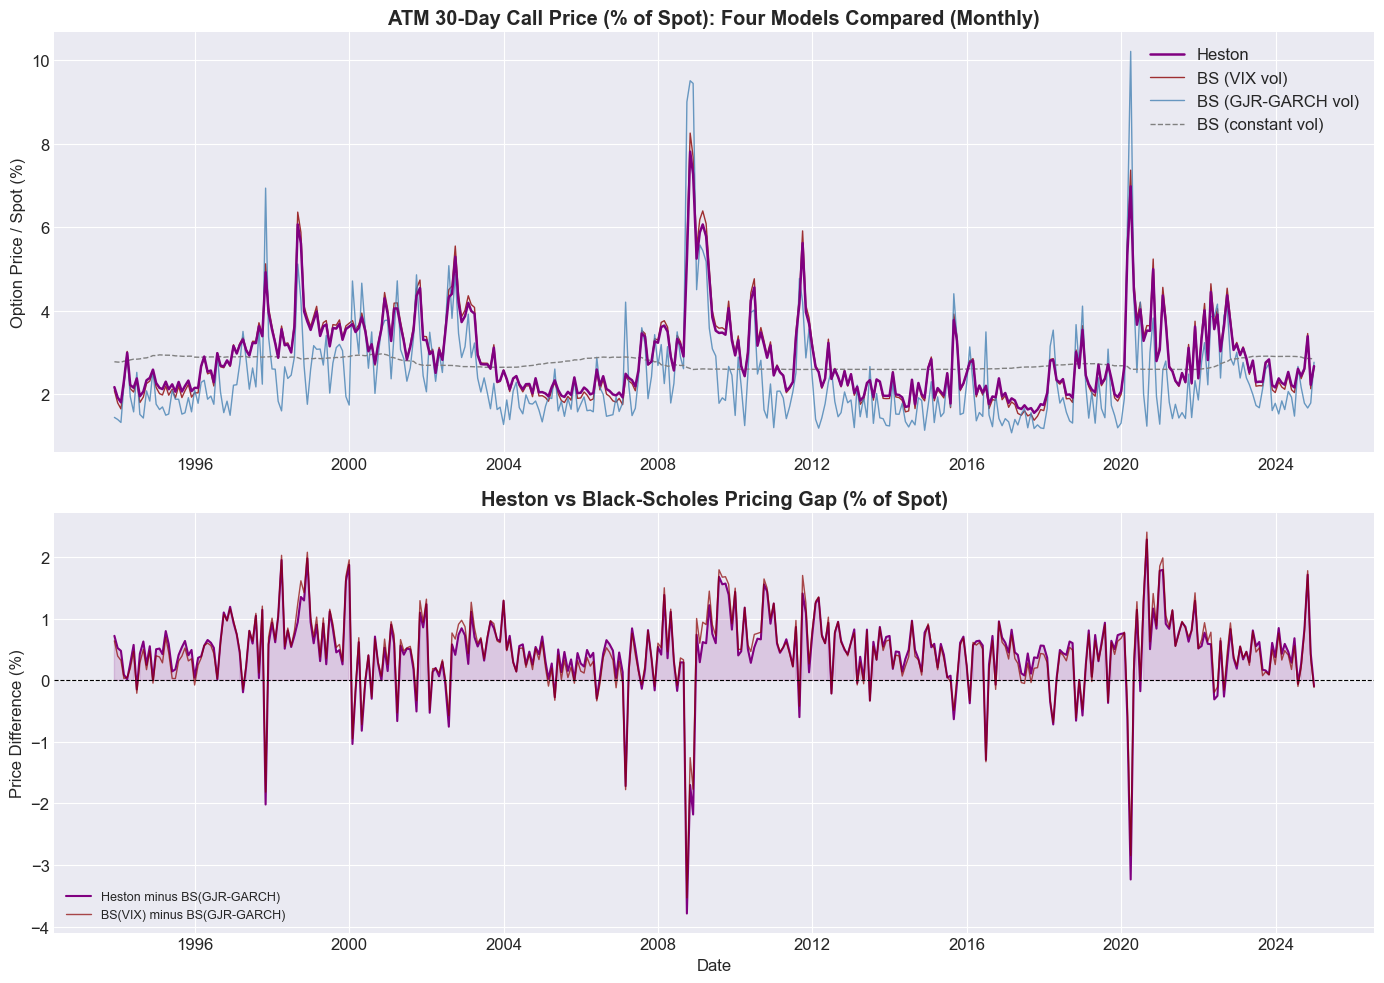

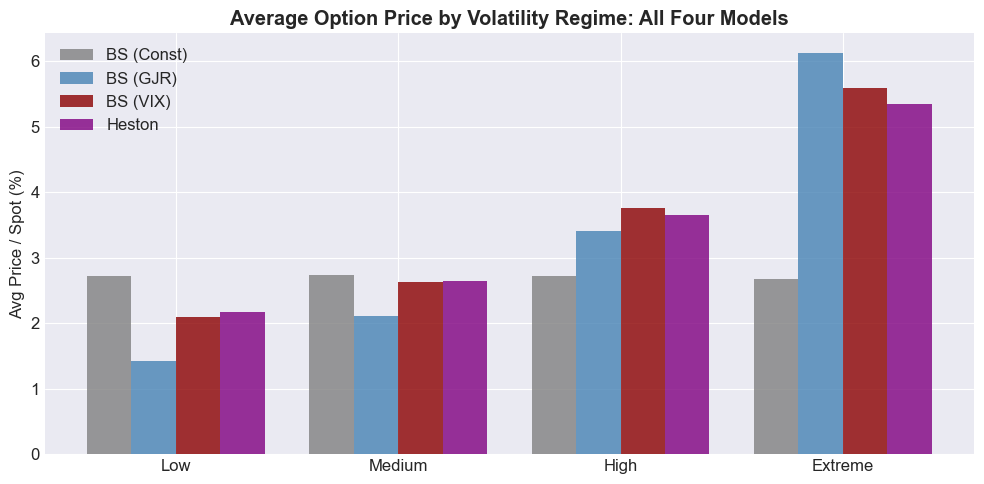


Average price by regime:
  Low     : Const=2.726%  GJR=1.423%  VIX=2.097%  Heston=2.172%
  Medium  : Const=2.737%  GJR=2.111%  VIX=2.635%  Heston=2.643%
  High    : Const=2.729%  GJR=3.413%  VIX=3.766%  Heston=3.658%
  Extreme : Const=2.682%  GJR=6.123%  VIX=5.599%  Heston=5.342%


In [20]:
from scipy.integrate import quad

def heston_call(S, K, T, r, v0, kappa, theta, sigma_v, rho):
    """Heston (1993) call price via characteristic function integration."""
    if T <= 1e-6:
        return float(max(S - K, 0.0))
    x = np.log(S / K)

    def heston_P(j):
        u = 0.5 if j == 1 else -0.5
        b = (kappa - rho * sigma_v) if j == 1 else kappa
        def integrand(phi):
            d   = np.sqrt((rho * sigma_v * 1j * phi - b)**2 -
                          sigma_v**2 * (2 * u * 1j * phi - phi**2))
            g   = (b - rho*sigma_v*1j*phi + d) / (b - rho*sigma_v*1j*phi - d)
            edT = np.exp(d * T)
            C = (r * 1j * phi * T +
                 kappa * theta / sigma_v**2 * (
                     (b - rho*sigma_v*1j*phi + d) * T -
                     2 * np.log((1 - g * edT) / (1 - g))))
            D = ((b - rho*sigma_v*1j*phi + d) / sigma_v**2 *
                 (1 - edT) / (1 - g * edT))
            return np.real(np.exp(C + D * v0 + 1j * phi * x) / (1j * phi))
        val, _ = quad(integrand, 1e-8, 300, limit=300, epsabs=1e-6, epsrel=1e-6)
        return 0.5 + val / np.pi

    try:
        return float(S * heston_P(1) - K * np.exp(-r * T) * heston_P(2))
    except Exception:
        return float(black_scholes_call(S, K, T, r, np.sqrt(max(v0, 1e-6))))

# ── Heston parameters ─────────────────────────────────────────────────────────
KAPPA   = 2.0
THETA   = fred_data['VIX'].dropna().mean() ** 2
SIGMA_V = 0.30
RHO     = -0.70
T_OPT   = 30 / 252

# ── Monthly sample (last trading day of each month) ───────────────────────────
monthly_dates = [grp.index[-1] for _, grp in pricing.groupby(pricing.index.to_period('M'))]
monthly_idx   = pd.DatetimeIndex(monthly_dates)

print(f"Computing Heston prices for {len(monthly_idx)} months...")
heston_rows = []
for dt in monthly_idx:
    S   = pricing.loc[dt, 'Spot']
    r_  = pricing.loc[dt, 'TBill']
    vix_today = fred_aligned['VIX'].get(dt, fred_aligned['VIX'].mean())
    v0  = max(vix_today ** 2, 1e-6)
    hp  = heston_call(S, S, T_OPT, r_, v0, KAPPA, THETA, SIGMA_V, RHO)
    heston_rows.append({'Date': dt, 'Heston_pct': hp / S * 100})

heston_monthly = pd.DataFrame(heston_rows).set_index('Date')
compare = pricing.loc[monthly_idx, ['BS_Const_pct','BS_GJR_pct','BS_VIX_pct','Regime']].copy()
compare['Heston_pct'] = heston_monthly['Heston_pct']

print(f"\nMean ATM 30-day call price as % of spot:")
print(f"  Black-Scholes (Constant vol):  {compare['BS_Const_pct'].mean():.3f}%")
print(f"  Black-Scholes (GJR-GARCH vol): {compare['BS_GJR_pct'].mean():.3f}%")
print(f"  Black-Scholes (VIX vol):       {compare['BS_VIX_pct'].mean():.3f}%")
print(f"  Heston Model:                  {compare['Heston_pct'].mean():.3f}%")

# ── Chart 1: All four model prices over time ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
ax = axes[0]
ax.plot(compare.index, compare['Heston_pct'],   label='Heston',            color='purple',    lw=1.8, zorder=5)
ax.plot(compare.index, compare['BS_VIX_pct'],   label='BS (VIX vol)',      color='darkred',   lw=1,   alpha=0.8)
ax.plot(compare.index, compare['BS_GJR_pct'],   label='BS (GJR-GARCH vol)',color='steelblue', lw=1,   alpha=0.8)
ax.plot(compare.index, compare['BS_Const_pct'], label='BS (constant vol)', color='grey',      lw=1,   ls='--')
ax.set_title('ATM 30-Day Call Price (% of Spot): Four Models Compared (Monthly)', fontweight='bold')
ax.set_ylabel('Option Price / Spot (%)')
ax.legend()

ax = axes[1]
ax.plot(compare.index, compare['Heston_pct'] - compare['BS_GJR_pct'],
        label='Heston minus BS(GJR-GARCH)', color='purple', lw=1.5)
ax.plot(compare.index, compare['BS_VIX_pct'] - compare['BS_GJR_pct'],
        label='BS(VIX) minus BS(GJR-GARCH)', color='darkred', lw=1, alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(compare.index, 0, compare['Heston_pct'] - compare['BS_GJR_pct'],
                where=(compare['Heston_pct'] > compare['BS_GJR_pct']),
                alpha=0.15, color='purple')
ax.set_title('Heston vs Black-Scholes Pricing Gap (% of Spot)', fontweight='bold')
ax.set_ylabel('Price Difference (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig14_heston_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chart 2: Average price by regime, all four models ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(regime_order))
width  = 0.2
models = [('BS_Const_pct','BS (Const)','grey'),
          ('BS_GJR_pct',  'BS (GJR)',  'steelblue'),
          ('BS_VIX_pct',  'BS (VIX)',  'darkred'),
          ('Heston_pct',  'Heston',    'purple')]
for i, (col, label, color) in enumerate(models):
    means = [compare.loc[compare['Regime']==r, col].mean() for r in regime_order]
    ax.bar(x + i*width, means, width, label=label, color=color, alpha=0.8)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(regime_order)
ax.set_title('Average Option Price by Volatility Regime: All Four Models', fontweight='bold')
ax.set_ylabel('Avg Price / Spot (%)')
ax.legend()
plt.tight_layout()
plt.savefig('fig15_heston_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAverage price by regime:')
for r in regime_order:
    sub = compare[compare['Regime'] == r]
    print(f'  {r:8s}: Const={sub["BS_Const_pct"].mean():.3f}%  '
          f'GJR={sub["BS_GJR_pct"].mean():.3f}%  '
          f'VIX={sub["BS_VIX_pct"].mean():.3f}%  '
          f'Heston={sub["Heston_pct"].mean():.3f}%')


## 9. Insights & Conclusions

### 9.1 Summary Statistics Table

In [21]:
vrp_series = (fred_aligned['VIX'] - spy_aligned['RV_21']) * 100

summary = pd.DataFrame({
    'Metric': [
        'Full SPY period', 'Total SPY trading days',
        'SPY annualised return', 'SPY annualised volatility', 'SPY max drawdown',
        'Excess kurtosis (fat tails)', 'Normality rejected (Jarque-Bera)',
        'GARCH alpha', 'GARCH beta', 'GARCH vol shock half-life',
        'GJR gamma (leverage effect)', 'GJR AIC improvement over GARCH',
        'Average variance risk premium (VIX-RV)',
        'VIX > realised vol (% of days)',
        'VIX term structure inverted (% of days)',
        'Avg pricing error — Low regime',
        'Avg pricing error — Extreme regime',
        'Max pricing error (crisis peak)'
    ],
    'Value': [
        f'{spy.index[0].date()} – {spy.index[-1].date()}',
        f'{len(spy):,}',
        f'{returns.mean() * 252:.2%}',
        f'{returns.std() * np.sqrt(252):.2%}',
        f"{((spy['Close'] / spy['Close'].cummax()) - 1).min():.2%}",
        f'{kurtosis:.2f}  (normal = 0)',
        f'Yes (p = {jb_p:.2e})',
        f'{alpha_g:.4f}',
        f'{beta_g:.4f}',
        f'{np.log(0.5)/np.log(alpha_g+beta_g):.1f} trading days',
        f'{gamma_gj:.4f}  (bad news has {(alpha_gj+gamma_gj)/alpha_gj:.1f}x the vol impact of good news)',
        f'{garch_fit.aic - gjr_fit.aic:.1f} AIC points',
        f'{vrp_series.mean():.2f}%',
        f'{(vrp_series > 0).mean():.1%}',
        f'{(fred_data[["VIX","VIX3M"]].dropna()["VIX"] > fred_data[["VIX","VIX3M"]].dropna()["VIX3M"]).mean():.1%}',
        f'{pricing.loc[pricing["Regime"]=="Low",    "GJR_vs_Const"].mean():.4f}% of spot',
        f'{pricing.loc[pricing["Regime"]=="Extreme","GJR_vs_Const"].mean():.4f}% of spot',
        f'{pricing["GJR_vs_Const"].max():.4f}% of spot'
    ]
})
print(summary.to_string(index=False))

                                 Metric                                                    Value
                        Full SPY period                                  1993-11-11 – 2024-12-30
                 Total SPY trading days                                                    7,838
                  SPY annualised return                                                    9.98%
              SPY annualised volatility                                                   18.80%
                       SPY max drawdown                                                  -55.19%
            Excess kurtosis (fat tails)                                      10.89  (normal = 0)
       Normality rejected (Jarque-Bera)                                       Yes (p = 0.00e+00)
                            GARCH alpha                                                   0.1167
                             GARCH beta                                                   0.8677
              GARCH vol shock 

### 9.2 Key Findings

**1. Volatility is highly time-varying — the constant-vol assumption does not hold**
Over 7,838 trading days, SPY's annualized volatility ranged from under 8% in calm periods to over 60% during the 2008 financial crisis. Excess kurtosis of **10.89** and a Jarque-Bera p-value of essentially zero confirm that the normal distribution Black-Scholes relies on is statistically rejected by the data.

**2. SPY returns are fat-tailed and negatively skewed — crash risk is structurally underpriced by normal-distribution models**
Skewness of **−0.294** and excess kurtosis of **10.89** mean the empirical return distribution has a heavier left tail than a normal distribution predicts. This directly undermines Black-Scholes: rare large losses are not rare enough to ignore.

**3. GJR-GARCH captures a meaningful asymmetry — bad news hits volatility 27× harder than good news**
The estimated leverage coefficient γ = **0.173** (vs. α = **0.007**) means a negative return shock raises conditional variance by roughly 27× more than an equivalently-sized positive shock. GJR-GARCH's AIC of **21,128** represents a **257-point improvement** over GARCH(1,1)'s 21,385, a substantial gain from a single additional parameter.

**4. The market systematically overprices implied volatility — the variance risk premium is persistent**
VIX exceeded 21-day realized volatility on **85.3% of trading days**, with an average premium of **3.67 annualized volatility points**. This is not a forecasting failure but a structural risk premium: options sellers demand compensation for the convex volatility exposure they bear, and buyers consistently pay it.

**5. VIX term structure inversions mark acute, near-term panic**
The term structure inverted on **10.1% of trading days**, with inversions tightly clustered around the 2008 crisis, the 2020 COVID shock, and the 2022 rate cycle. The signal distinguishes short-term panic from prolonged uncertainty, VIX3M tends to stay elevated even as near-term fear subsides.

**6. Black-Scholes mispricing scales sharply with market stress**
Relative to GJR-GARCH-based pricing, constant-vol Black-Scholes produced average mispricing of **−1.30%** of spot in the Low regime and **+3.67%** in the Extreme regime, peaking at **+13.1%** during the most acute crisis periods. This is not a rounding error, it represents a systematic and regime-dependent bias that grows precisely when accurate pricing matters most.

**7. Gold provides genuine volatility diversification; technology amplifies equity risk**
SPY-QQQ volatility correlation was **0.952** over the full sample — the two assets move almost in lockstep during stress. SPY-GLD correlation was **0.577**, and GLD showed no leverage effect (γ = −0.023), meaning gold volatility does not spike on negative return shocks the way equity volatility does. This confirms gold's structural role as a diversifier, not simply an uncorrelated asset.

### 9.3 Limitations & Extensions

- Without real options market prices, our Black-Scholes outputs are theoretical — calibrating to market prices would reveal the implied volatility surface and the well-known volatility smile
- Adding **EGARCH** would model the log of variance rather than the variance itself, removing the non-negativity constraint on parameters
- A **jump-diffusion model** (Merton, 1976) would capture instantaneous price jumps that GARCH, as a daily model, cannot fully account for
- Extending to **multivariate GARCH** (DCC-GARCH) would model time-varying correlations between SPY, QQQ, and GLD simultaneously

## References

Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3), 637–654.

Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.

Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007.

Glosten, L. R., Jagannathan, R., & Runkle, D. E. (1993). On the relation between the expected value and the volatility of the nominal excess return on stocks. *Journal of Finance*, 48(5), 1779–1801.

Heston, S. L. (1993). A closed-form solution for options with stochastic volatility with applications to bond and currency options. *Review of Financial Studies*, 6(2), 327–343.

Jarque, C. M., & Bera, A. K. (1987). A test for normality of observations and regression residuals. *International Statistical Review*, 55(2), 163–172.

Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time series models. *Biometrika*, 65(2), 297–303.

Merton, R. C. (1976). Option pricing when underlying stock returns are discontinuous. *Journal of Financial Economics*, 3(1–2), 125–144.